# 1. Setup and Database Connection

In [5]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [6]:
current_dir = Path.cwd().resolve()
project_name = 'ride-hailing-demand-fleet-allocation'

if current_dir.name == project_name:
    project_root = current_dir
elif current_dir.name == 'notebooks' and current_dir.parent.name == project_name:
    project_root = current_dir.parent
else:
    project_root = current_dir / project_name

database_path = project_root / 'data' / 'processed' / 'nyc_taxi.db'

if not database_path.exists():
    raise FileNotFoundError(f'Database not found: {database_path}')

In [7]:
con = duckdb.connect(database_path.as_posix(), read_only=True)

print(f'Database: {database_path}')
print('Connection mode: read only')

Database: D:\My Journey\Data Project\ride-hailing-demand-fleet-allocation\data\processed\nyc_taxi.db
Connection mode: read only


In [8]:
df_tables = con.execute("SHOW TABLES").df()
df_tables

,name
0,dim_base
1,dim_time
2,dim_zone
3,fact_trip
4,fleet_allocation_recommendation
5,forecast_model_evaluation
6,forecast_output
7,forecast_test_tier_evaluation


# 2. Temporal Demand Patterns

## a. Trip demand by hour of day

In [9]:
df_hourly = con.execute("""
    SELECT
        EXTRACT(HOUR FROM pickup_datetime) AS hour_of_day,
        COUNT(*) AS total_completed_trips,
        COUNT(*) * 1.0
            / COUNT(DISTINCT CAST(pickup_datetime AS DATE))
            AS avg_completed_trips_per_day
    FROM fact_trip
    GROUP BY hour_of_day
    ORDER BY hour_of_day
""").df()

df_hourly

,hour_of_day,total_completed_trips,avg_completed_trips_per_day
0,0,8849177,24178.079235
1,1,6184160,16896.612022
2,2,4431115,12106.871585
3,3,3564902,9740.169399
4,4,3698093,10104.079235
5,5,4309086,11773.459016
6,6,6674147,18235.374317
7,7,9988980,27292.295082
8,8,12060335,32951.734973
9,9,11134217,30421.357923


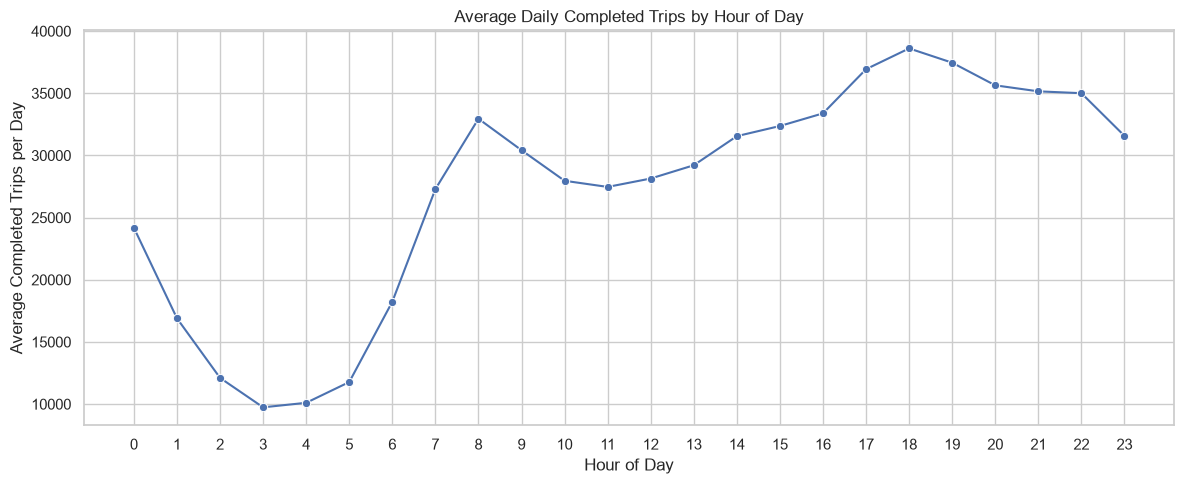

In [10]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=df_hourly,
    x='hour_of_day',
    y='avg_completed_trips_per_day',
    marker='o'
)

plt.title('Average Daily Completed Trips by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Completed Trips per Day')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [11]:
peak_hour = df_hourly.loc[
    df_hourly['avg_completed_trips_per_day'].idxmax()
]

lowest_hour = df_hourly.loc[
    df_hourly['avg_completed_trips_per_day'].idxmin()
]

print(
    f"Peak hour   : {int(peak_hour['hour_of_day']):02d}:00 "
    f"({peak_hour['avg_completed_trips_per_day']:,.0f} trips/day)"
)

print(
    f"Lowest hour : {int(lowest_hour['hour_of_day']):02d}:00 "
    f"({lowest_hour['avg_completed_trips_per_day']:,.0f} trips/day)"
)

Peak hour   : 18:00 (38,609 trips/day)
Lowest hour : 03:00 (9,740 trips/day)


## b. Trip demand by day of week

In [12]:
df_day_of_week = con.execute("""
    WITH daily_trips AS (
        SELECT
            CAST(pickup_datetime AS DATE) AS trip_date,
            DAYNAME(pickup_datetime) AS day_name,
            ISODOW(pickup_datetime) AS day_number,
            COUNT(*) AS completed_trips
        FROM fact_trip
        GROUP BY trip_date, day_name, day_number
    )

    SELECT
        day_name,
        day_number,
        AVG(completed_trips) AS avg_completed_trips
    FROM daily_trips
    GROUP BY day_name, day_number
    ORDER BY day_number
""").df()

df_day_of_week

,day_name,day_number,avg_completed_trips
0,Monday,1,562977.566038
1,Tuesday,2,589682.113208
2,Wednesday,3,624028.480769
3,Thursday,4,657596.000000
4,Friday,5,718859.442308
5,Saturday,6,769356.615385
6,Sunday,7,659693.576923


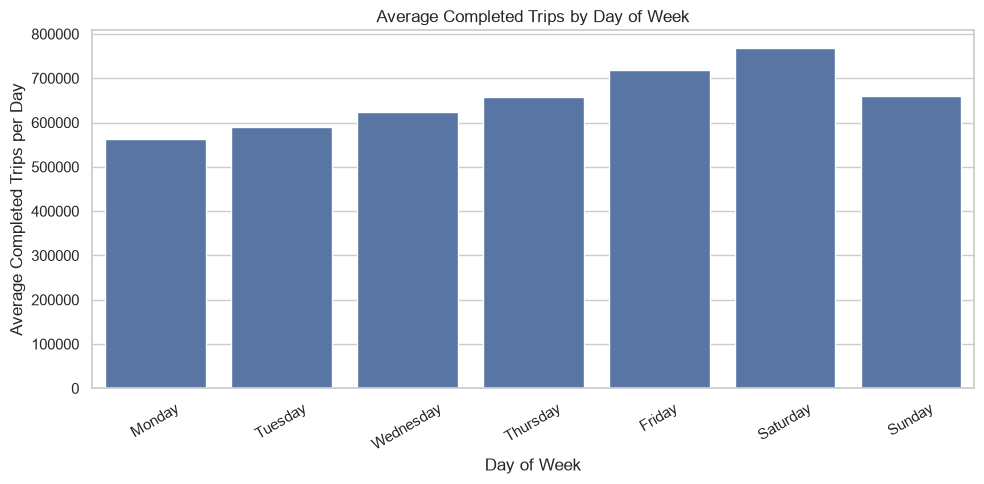

In [13]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_day_of_week,
    x='day_name',
    y='avg_completed_trips',
    order=df_day_of_week['day_name']
)

plt.title('Average Completed Trips by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Completed Trips per Day')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## c. Trip demand weekday vs weekend

In [14]:
df_day_type = con.execute("""
    WITH daily_trips AS (
        SELECT
            CAST(pickup_datetime AS DATE) AS trip_date,
            CASE
                WHEN ISODOW(pickup_datetime) IN (6, 7)
                THEN 'Weekend'
                ELSE 'Weekday'
            END AS day_type,
            COUNT(*) AS completed_trips
        FROM fact_trip
        GROUP BY trip_date, day_type
    )

    SELECT
        day_type,
        COUNT(*) AS number_of_days,
        AVG(completed_trips) AS avg_completed_trips
    FROM daily_trips
    GROUP BY day_type
""").df()

df_day_type

,day_type,number_of_days,avg_completed_trips
0,Weekday,262,630214.225191
1,Weekend,104,714525.096154


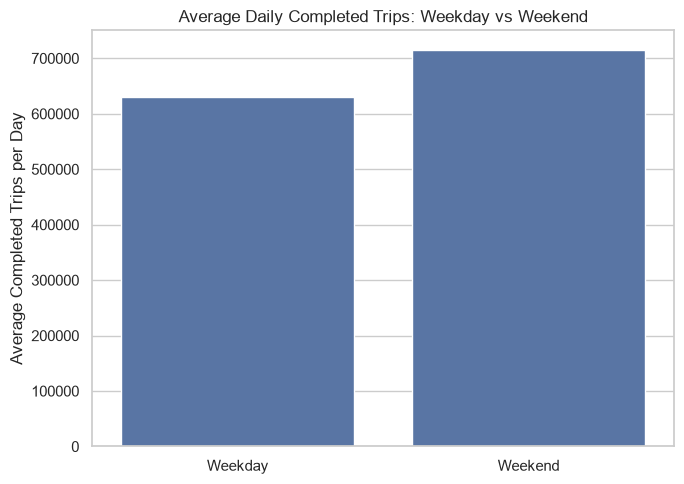

In [15]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_day_type,
    x='day_type',
    y='avg_completed_trips',
    order=['Weekday', 'Weekend']
)

plt.title('Average Daily Completed Trips: Weekday vs Weekend')
plt.xlabel('')
plt.ylabel('Average Completed Trips per Day')
plt.tight_layout()
plt.show()

# 3. Spatial Demand Patterns

## a. Demand per pickup borough

In [16]:
df_pickup_borough = con.execute("""
    SELECT
        zone.Borough AS pickup_borough,
        COUNT(*) AS total_completed_trips
    FROM fact_trip AS trip
    JOIN dim_zone AS zone
        ON trip.PULocationID = zone.LocationID
    GROUP BY pickup_borough
    ORDER BY total_completed_trips DESC
""").df()

total_borough_trips = df_pickup_borough['total_completed_trips'].sum()

df_pickup_borough['trip_share_pct'] = (
    df_pickup_borough['total_completed_trips']
    / total_borough_trips
    * 100
)

df_pickup_borough

,pickup_borough,total_completed_trips,trip_share_pct
0,Manhattan,93072715,38.873150
1,Brooklyn,63160990,26.380091
2,Queens,50089983,20.920798
3,Bronx,29568411,12.349670
4,Staten Island,3525193,1.472347
5,N/A,9430,0.003939
6,EWR,15,0.000006


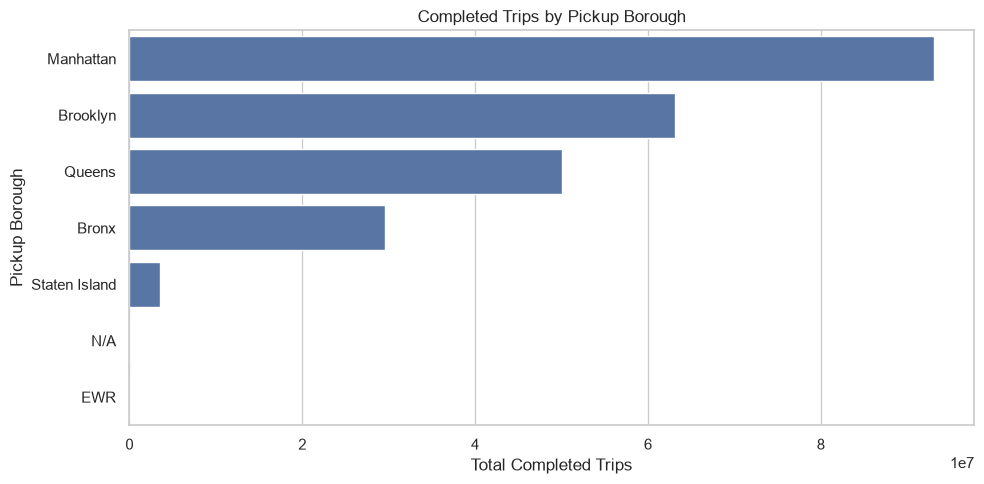

In [17]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_pickup_borough,
    x='total_completed_trips',
    y='pickup_borough'
)

plt.title('Completed Trips by Pickup Borough')
plt.xlabel('Total Completed Trips')
plt.ylabel('Pickup Borough')
plt.tight_layout()
plt.show()

## b. Top pickup zones

In [18]:
df_top_pickup_zones = con.execute("""
    SELECT
        zone.LocationID,
        zone.Zone AS pickup_zone,
        zone.Borough AS pickup_borough,
        COUNT(*) AS total_completed_trips
    FROM fact_trip AS trip
    JOIN dim_zone AS zone
        ON trip.PULocationID = zone.LocationID
    WHERE zone.LocationID NOT IN (264, 265)
    GROUP BY
        zone.LocationID,
        zone.Zone,
        zone.Borough
    ORDER BY total_completed_trips DESC
    LIMIT 10
""").df()

df_top_pickup_zones

,LocationID,pickup_zone,pickup_borough,total_completed_trips
0,138,LaGuardia Airport,Queens,4738154
1,132,JFK Airport,Queens,4330406
2,79,East Village,Manhattan,3171508
3,61,Crown Heights North,Brooklyn,3136223
4,230,Times Sq/Theatre District,Manhattan,2939768
5,161,Midtown Center,Manhattan,2804606
6,231,TriBeCa/Civic Center,Manhattan,2713377
7,68,East Chelsea,Manhattan,2688071
8,37,Bushwick South,Brooklyn,2587035
9,246,West Chelsea/Hudson Yards,Manhattan,2570265


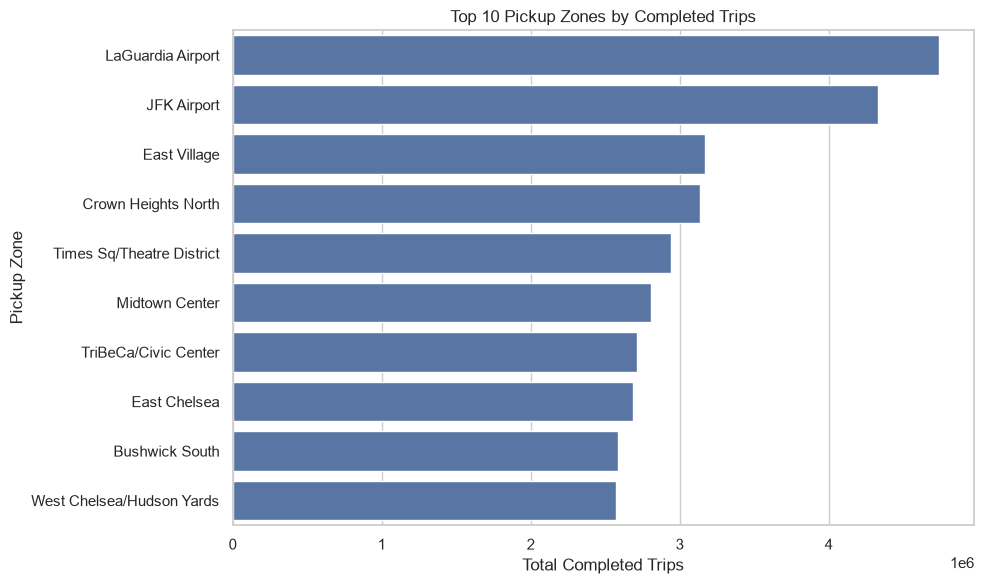

In [19]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_top_pickup_zones,
    x='total_completed_trips',
    y='pickup_zone'
)

plt.title('Top 10 Pickup Zones by Completed Trips')
plt.xlabel('Total Completed Trips')
plt.ylabel('Pickup Zone')
plt.tight_layout()
plt.show()

## c. Borough routes

In [20]:
df_borough_routes = con.execute("""
    SELECT
        pickup.Borough AS pickup_borough,
        dropoff.Borough AS dropoff_borough,
        COUNT(*) AS total_completed_trips
    FROM fact_trip AS trip
    JOIN dim_zone AS pickup
        ON trip.PULocationID = pickup.LocationID
    JOIN dim_zone AS dropoff
        ON trip.DOLocationID = dropoff.LocationID
    GROUP BY
        pickup.Borough,
        dropoff.Borough
    ORDER BY total_completed_trips DESC
    LIMIT 10
""").df()

df_borough_routes

,pickup_borough,dropoff_borough,total_completed_trips
0,Manhattan,Manhattan,64532356
1,Brooklyn,Brooklyn,47534061
2,Queens,Queens,32226260
3,Bronx,Bronx,21528967
4,Manhattan,Queens,9146675
5,Manhattan,Brooklyn,8215948
6,Queens,Manhattan,7460274
7,Brooklyn,Manhattan,7266287
8,Brooklyn,Queens,6862285
9,Queens,Brooklyn,6149209


# 4. Trip Distance and Duration Distribution

## a. Overall trip characteristics

In [21]:
df_trip_summary = con.execute("""
    SELECT
        COUNT(*) AS total_completed_trips,
        ROUND(AVG(trip_miles), 2) AS avg_trip_miles,
        ROUND(APPROX_QUANTILE(trip_miles, 0.5), 2) AS median_trip_miles,
        ROUND(APPROX_QUANTILE(trip_miles, 0.9), 2) AS p90_trip_miles,
        ROUND(AVG(trip_time) / 60.0, 2) AS avg_trip_minutes,
        ROUND(APPROX_QUANTILE(trip_time, 0.5) / 60.0, 2) AS median_trip_minutes,
        ROUND(APPROX_QUANTILE(trip_time, 0.9) / 60.0, 2) AS p90_trip_minutes
    FROM fact_trip
""").df()

df_trip_summary

,total_completed_trips,avg_trip_miles,median_trip_miles,p90_trip_miles,avg_trip_minutes,median_trip_minutes,p90_trip_minutes
0,239426737,5.08,3.01,11.66,20.13,16.32,38.52


## b. Trip characteristics by pickup borough

In [22]:
df_trip_by_borough = con.execute("""
    SELECT
        zone.Borough AS pickup_borough,
        COUNT(*) AS total_completed_trips,
        ROUND(AVG(trip.trip_miles), 2) AS avg_trip_miles,
        ROUND(APPROX_QUANTILE(trip.trip_miles, 0.5), 2) AS median_trip_miles,
        ROUND(AVG(trip.trip_time) / 60.0, 2) AS avg_trip_minutes,
        ROUND(APPROX_QUANTILE(trip.trip_time, 0.5) / 60.0, 2) AS median_trip_minutes
    FROM fact_trip AS trip
    JOIN dim_zone AS zone
        ON trip.PULocationID = zone.LocationID
    WHERE zone.Borough NOT IN ('N/A', 'EWR')
    GROUP BY pickup_borough
    ORDER BY total_completed_trips DESC
""").df()

df_trip_by_borough

,pickup_borough,total_completed_trips,avg_trip_miles,median_trip_miles,avg_trip_minutes,median_trip_minutes
0,Manhattan,93072715,5.08,2.89,21.18,17.60
1,Brooklyn,63160990,4.26,2.73,19.15,15.60
2,Queens,50089983,6.50,4.04,21.63,16.75
3,Bronx,29568411,4.40,2.88,16.86,14.07
4,Staten Island,3525193,5.27,3.15,16.16,12.18


In [23]:
df_trip_sample = con.execute("""
    SELECT
        zone.Borough AS pickup_borough,
        trip_sample.trip_miles,
        trip_sample.trip_time / 60.0 AS trip_minutes
    FROM (
        SELECT
            PULocationID,
            trip_miles,
            trip_time
        FROM fact_trip
        USING SAMPLE reservoir(100000 ROWS)
        REPEATABLE (42)
    ) AS trip_sample
    JOIN dim_zone AS zone
        ON trip_sample.PULocationID = zone.LocationID
    WHERE zone.Borough NOT IN ('N/A', 'EWR')
""").df()

df_trip_sample.head()

,pickup_borough,trip_miles,trip_minutes
0,Manhattan,0.936,6.100000
1,Queens,1.920,9.183333
2,Brooklyn,10.500,21.983333
3,Queens,9.650,69.050000
4,Queens,9.860,42.383333


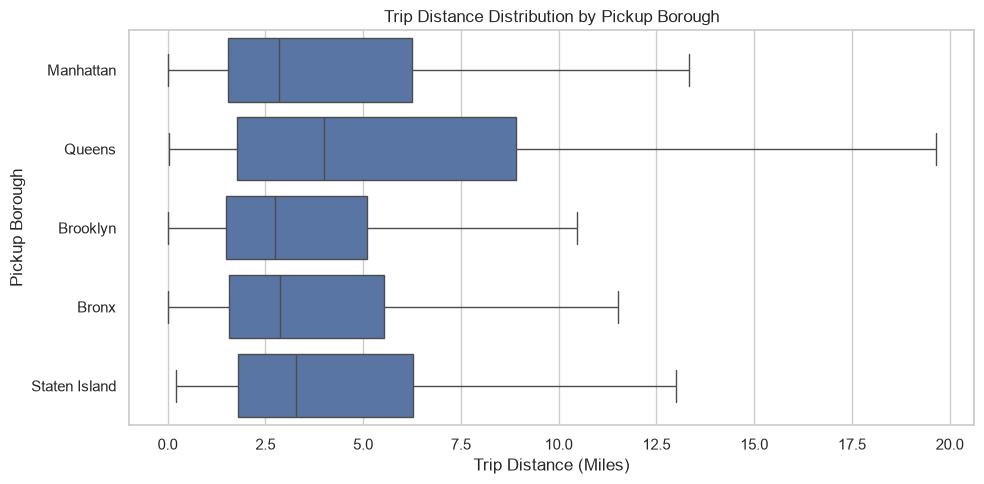

In [24]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_trip_sample,
    x='trip_miles',
    y='pickup_borough',
    showfliers=False
)

plt.title('Trip Distance Distribution by Pickup Borough')
plt.xlabel('Trip Distance (Miles)')
plt.ylabel('Pickup Borough')
plt.tight_layout()
plt.show()

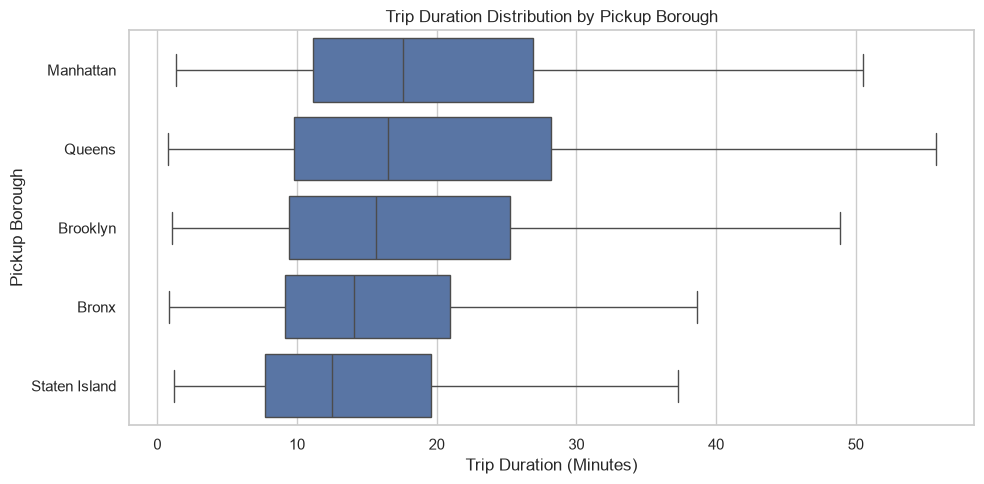

In [25]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_trip_sample,
    x='trip_minutes',
    y='pickup_borough',
    showfliers=False
)

plt.title('Trip Duration Distribution by Pickup Borough')
plt.xlabel('Trip Duration (Minutes)')
plt.ylabel('Pickup Borough')
plt.tight_layout()
plt.show()

## c. Trip duration by pickup hour

In [26]:
df_duration_by_hour = con.execute("""
    SELECT
        EXTRACT(HOUR FROM pickup_datetime) AS hour_of_day,
        ROUND(AVG(trip_miles), 2) AS avg_trip_miles,
        ROUND(AVG(trip_time) / 60.0, 2) AS avg_trip_minutes,
        ROUND(APPROX_QUANTILE(trip_time, 0.5) / 60.0, 2) AS median_trip_minutes
    FROM fact_trip
    GROUP BY hour_of_day
    ORDER BY hour_of_day
""").df()

df_duration_by_hour

,hour_of_day,avg_trip_miles,avg_trip_minutes,median_trip_minutes
0,0,5.38,17.81,15.05
1,1,5.26,16.88,14.43
2,2,5.37,16.61,14.33
3,3,6.05,17.11,14.92
4,4,7.11,18.10,16.08
5,5,7.29,18.98,16.38
6,6,6.33,19.44,16.08
7,7,5.14,19.71,15.82
8,8,4.62,19.48,15.65
9,9,4.74,19.28,15.65


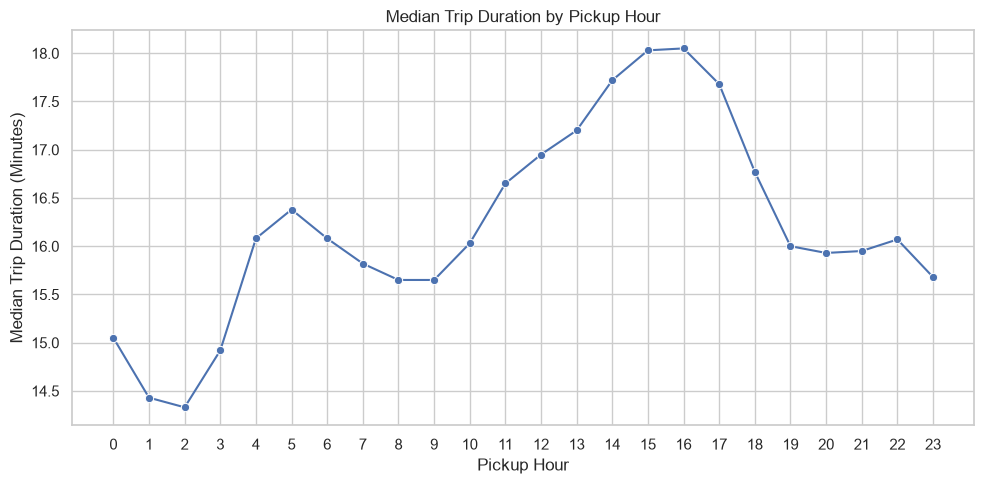

In [27]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df_duration_by_hour,
    x='hour_of_day',
    y='median_trip_minutes',
    marker='o'
)

plt.title('Median Trip Duration by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Median Trip Duration (Minutes)')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

# 5. Zone Demand Stability

## a. Calculate daily zone demand

In [35]:
df_daily_zone = con.execute("""
    SELECT
        CAST(trip.pickup_datetime AS DATE) AS demand_date,
        trip.PULocationID AS LocationID,
        zone.Zone AS pickup_zone,
        zone.Borough AS pickup_borough,
        COUNT(*) AS completed_trips,
        SUM(trip.trip_time) / 3600.0 AS completed_trip_hours
    FROM fact_trip AS trip
    JOIN dim_zone AS zone
        ON trip.PULocationID = zone.LocationID
    WHERE zone.LocationID NOT IN (264, 265)
      AND zone.Borough <> 'EWR'
    GROUP BY 1, 2, 3, 4
    ORDER BY 1, 2
""").df()

df_daily_zone['demand_date'] = pd.to_datetime(df_daily_zone['demand_date'])
df_daily_zone.head()

,demand_date,LocationID,pickup_zone,pickup_borough,completed_trips,completed_trip_hours
0,2024-01-01,2,Jamaica Bay,Queens,1,0.254444
1,2024-01-01,3,Allerton/Pelham Gardens,Bronx,1221,299.969722
2,2024-01-01,4,Alphabet City,Manhattan,2266,712.804167
3,2024-01-01,5,Arden Heights,Staten Island,172,48.806944
4,2024-01-01,6,Arrochar/Fort Wadsworth,Staten Island,291,82.192222


## b. Check daily coverage

In [36]:
df_zone_coverage = (
    df_daily_zone.groupby(['LocationID', 'pickup_zone', 'pickup_borough'])
    .agg(number_of_days=('demand_date', 'nunique'))
    .reset_index()
)

calendar_days = df_daily_zone['demand_date'].nunique()
df_zone_coverage['missing_days'] = calendar_days - df_zone_coverage['number_of_days']

display(df_zone_coverage.sort_values('number_of_days').head(10))
print(f'Zones observed       : {len(df_zone_coverage):,}')
print(f'Calendar days        : {calendar_days:,}')
print(f'Zones with full year : {(df_zone_coverage["missing_days"] == 0).sum():,}')
print(f'Zones missing days   : {(df_zone_coverage["missing_days"] > 0).sum():,}')

,LocationID,pickup_zone,pickup_borough,number_of_days,missing_days
101,105,Governor's Island/Ellis Island/Liberty Island,Manhattan,42,324
195,199,Rikers Island,Bronx,60,306
0,2,Jamaica Bay,Queens,247,119
106,110,Great Kills Park,Staten Island,251,115
256,260,Woodside,Queens,366,0
255,259,Woodlawn/Wakefield,Bronx,366,0
254,258,Woodhaven,Queens,366,0
253,257,Windsor Terrace,Brooklyn,366,0
252,256,Williamsburg (South Side),Brooklyn,366,0
251,255,Williamsburg (North Side),Brooklyn,366,0


Zones observed       : 260
Calendar days        : 366
Zones with full year : 256
Zones missing days   : 4


## c. Identify zones without recorded trips

In [37]:
df_actionable_zones = con.execute("""
    SELECT
        LocationID,
        Zone AS pickup_zone,
        Borough AS pickup_borough
    FROM dim_zone
    WHERE LocationID NOT IN (264, 265)
      AND Borough <> 'EWR'
    ORDER BY LocationID
""").df()

df_zones_without_trips = df_actionable_zones[
    ~df_actionable_zones['LocationID'].isin(df_daily_zone['LocationID'])
]

print(f'Actionable zones   : {len(df_actionable_zones):,}')
print(f'Zones without trips: {len(df_zones_without_trips):,}')
df_zones_without_trips

Actionable zones   : 262
Zones without trips: 2


,LocationID,pickup_zone,pickup_borough
101,103,Governor's Island/Ellis Island/Liberty Island,Manhattan
102,104,Governor's Island/Ellis Island/Liberty Island,Manhattan


## d. Complete all Date-Zones combination

In [38]:
df_calendar = con.execute("""
    SELECT DISTINCT calendar_date AS demand_date
    FROM dim_time
    ORDER BY demand_date
""").df()

df_calendar['demand_date'] = pd.to_datetime(df_calendar['demand_date'])

df_all_zone_days = df_calendar.merge(df_actionable_zones, how='cross')

df_daily_zone_complete = df_all_zone_days.merge(
    df_daily_zone[
        ['demand_date', 'LocationID', 'completed_trips', 'completed_trip_hours']
    ],
    on=['demand_date', 'LocationID'],
    how='left'
)

metric_columns = ['completed_trips', 'completed_trip_hours']
df_daily_zone_complete[metric_columns] = (
    df_daily_zone_complete[metric_columns].fillna(0)
)
df_daily_zone_complete['completed_trips'] = (
    df_daily_zone_complete['completed_trips'].astype(int)
)

print(f'Complete daily-zone rows: {len(df_daily_zone_complete):,}')
print(f'Zero-trip zone-days     : {(df_daily_zone_complete["completed_trips"] == 0).sum():,}')
print(f'Missing values          : {df_daily_zone_complete[metric_columns].isna().sum().sum():,}')

Complete daily-zone rows: 95,892
Zero-trip zone-days     : 1,596
Missing values          : 0


## e. Calculate zone demand stability

In [40]:
df_zone_stability = (
    df_daily_zone_complete
    .groupby(['LocationID', 'pickup_zone', 'pickup_borough'])
    .agg(
        avg_daily_trips=('completed_trips', 'mean'),
        std_daily_trips=('completed_trips', 'std'),
        min_daily_trips=('completed_trips', 'min'),
        max_daily_trips=('completed_trips', 'max')
    )
    .reset_index()
)

df_zone_stability['coefficient_of_variation'] = float('nan')
has_demand = df_zone_stability['avg_daily_trips'] > 0

df_zone_stability.loc[has_demand, 'coefficient_of_variation'] = (
    df_zone_stability.loc[has_demand, 'std_daily_trips']
    / df_zone_stability.loc[has_demand, 'avg_daily_trips']
)

round_columns = [
    'avg_daily_trips', 'std_daily_trips',
    'coefficient_of_variation'
]
df_zone_stability[round_columns] = df_zone_stability[round_columns].round(3)

df_top_zone_stability = (
    df_zone_stability[has_demand]
    .nlargest(10, 'avg_daily_trips')
)

df_top_zone_stability

,LocationID,pickup_zone,pickup_borough,avg_daily_trips,std_daily_trips,min_daily_trips,max_daily_trips,coefficient_of_variation
136,138,LaGuardia Airport,Queens,12945.776,2903.904,5343,21901,0.224
130,132,JFK Airport,Queens,11831.710,1930.403,6959,17907,0.163
77,79,East Village,Manhattan,8665.322,3223.743,3321,18878,0.372
59,61,Crown Heights North,Brooklyn,8568.915,1521.967,6031,12445,0.178
228,230,Times Sq/Theatre District,Manhattan,8032.153,1219.635,1522,11490,0.152
159,161,Midtown Center,Manhattan,7662.858,2138.371,3236,13225,0.279
229,231,TriBeCa/Civic Center,Manhattan,7413.598,1607.686,2721,11971,0.217
66,68,East Chelsea,Manhattan,7344.456,979.099,3696,10551,0.133
35,37,Bushwick South,Brooklyn,7068.402,2164.891,4332,14184,0.306
244,246,West Chelsea/Hudson Yards,Manhattan,7022.582,1381.634,2983,11551,0.197


In [83]:
df_top_zone_stability = (
    df_zone_stability
    .sort_values('avg_daily_trips', ascending=False)
    .head(10)
)

df_top_zone_stability

,LocationID,pickup_zone,pickup_borough,avg_daily_trips,std_daily_trips,min_daily_trips,max_daily_trips,coefficient_of_variation
136,138,LaGuardia Airport,Queens,12945.78,2903.90,5343,21901,0.224
130,132,JFK Airport,Queens,11831.71,1930.40,6959,17907,0.163
77,79,East Village,Manhattan,8665.32,3223.74,3321,18878,0.372
59,61,Crown Heights North,Brooklyn,8568.92,1521.97,6031,12445,0.178
228,230,Times Sq/Theatre District,Manhattan,8032.15,1219.64,1522,11490,0.152
159,161,Midtown Center,Manhattan,7662.86,2138.37,3236,13225,0.279
229,231,TriBeCa/Civic Center,Manhattan,7413.60,1607.69,2721,11971,0.217
66,68,East Chelsea,Manhattan,7344.46,979.10,3696,10551,0.133
35,37,Bushwick South,Brooklyn,7068.40,2164.89,4332,14184,0.306
244,246,West Chelsea/Hudson Yards,Manhattan,7022.58,1381.63,2983,11551,0.197


## f. Visualize demand and stability

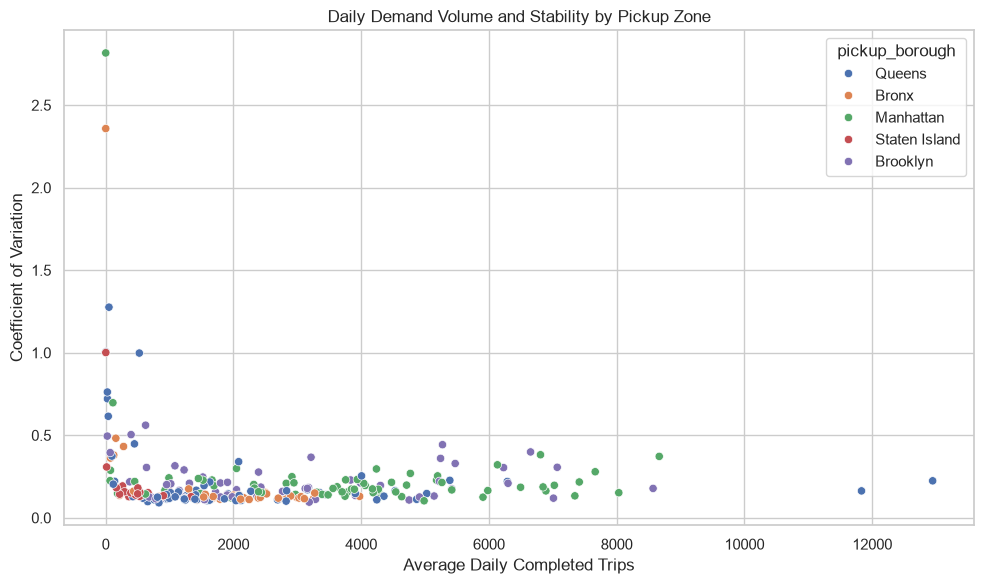

In [41]:
df_stability_plot = df_zone_stability[
    df_zone_stability['avg_daily_trips'] > 0
].copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_stability_plot,
    x='avg_daily_trips',
    y='coefficient_of_variation',
    hue='pickup_borough'
)

plt.title('Daily Demand Volume and Stability by Pickup Zone')
plt.xlabel('Average Daily Completed Trips')
plt.ylabel('Coefficient of Variation')
plt.tight_layout()
plt.show()

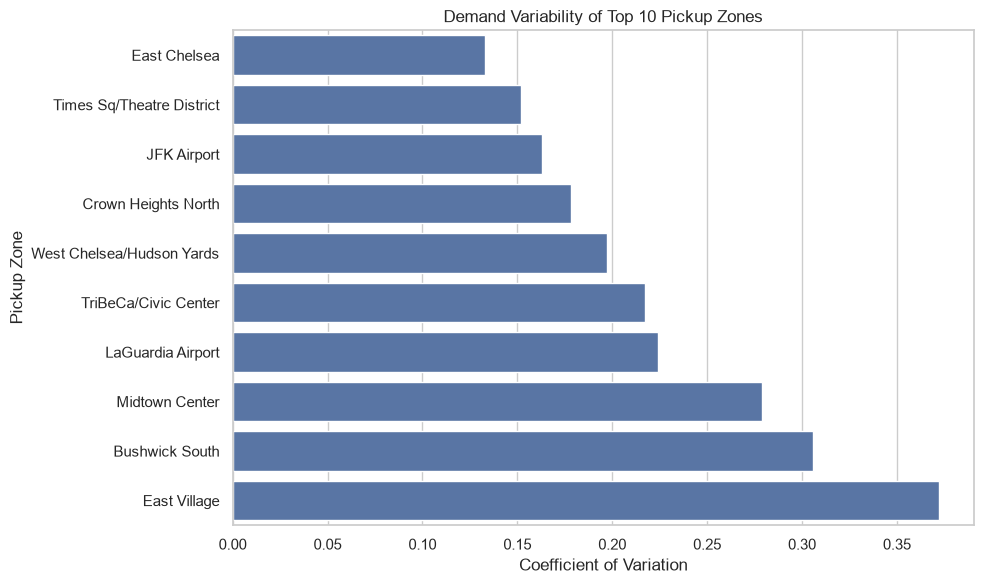

In [42]:
df_top_zone_stability_plot = df_top_zone_stability.sort_values(
    'coefficient_of_variation'
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_top_zone_stability_plot,
    x='coefficient_of_variation',
    y='pickup_zone'
)

plt.title('Demand Variability of Top 10 Pickup Zones')
plt.xlabel('Coefficient of Variation')
plt.ylabel('Pickup Zone')
plt.tight_layout()
plt.show()

# 6. Completed-Trip Activity Proxy

## a. Calculate daily completed-trip activity

In [49]:
df_daily_activity_raw = con.execute("""
    SELECT
        CAST(trip.pickup_datetime AS DATE) AS demand_date,
        trip.PULocationID AS LocationID,
        COUNT(*) AS completed_trips,
        SUM(trip.trip_time) / 3600.0 AS completed_trip_hours
    FROM fact_trip AS trip
    JOIN dim_zone AS zone
        ON trip.PULocationID = zone.LocationID
    WHERE zone.LocationID NOT IN (264, 265)
      AND zone.Borough <> 'EWR'
    GROUP BY
        demand_date,
        trip.PULocationID
    ORDER BY
        demand_date,
        trip.PULocationID
""").df()

display(df_daily_activity_raw.head())
print(f'Total daily-zone rows : {len(df_daily_zone):,}')
print(f'Minimum date          : {df_daily_zone["demand_date"].min()}')
print(f'Maximum date          : {df_daily_zone["demand_date"].max()}')

,demand_date,LocationID,completed_trips,completed_trip_hours
0,2024-01-01,2,1,0.254444
1,2024-01-01,3,1221,299.969722
2,2024-01-01,4,2266,712.804167
3,2024-01-01,5,172,48.806944
4,2024-01-01,6,291,82.192222


Total daily-zone rows : 94,296
Minimum date          : 2024-01-01 00:00:00
Maximum date          : 2024-12-31 00:00:00


## b. Complete missing date-zone combinations 

In [50]:
df_daily_activity = df_all_zone_days.merge(
    df_daily_activity_raw,
    on=['demand_date', 'LocationID'],
    how='left'
)

df_daily_activity[
    ['completed_trips', 'completed_trip_hours']
] = df_daily_activity[
    ['completed_trips', 'completed_trip_hours']
].fillna(0)

df_daily_activity['completed_trips'] = (
    df_daily_activity['completed_trips'].astype('int64')
)

print(f'Daily activity rows  : {len(df_daily_activity):,}')
print(f'Total completed trips: {df_daily_activity["completed_trips"].sum():,}')
print(f'Missing trip hours   : {df_daily_activity["completed_trip_hours"].isna().sum():,}')

Daily activity rows  : 95,892
Total completed trips: 239,417,292
Missing trip hours   : 0


## c. Create zone activity proxy

In [56]:
df_zone_activity = (
    df_daily_zone_complete
    .groupby(['LocationID', 'pickup_zone', 'pickup_borough'])
    .agg(
        avg_daily_completed_trips=('completed_trips', 'mean'),
        avg_completed_trip_hours_per_day=('completed_trip_hours', 'mean'),
        total_completed_trips=('completed_trips', 'sum'),
        total_completed_trip_hours=('completed_trip_hours', 'sum')
    )
    .reset_index()
)

df_zone_activity['avg_trip_minutes'] = float('nan')
has_trips = df_zone_activity['total_completed_trips'] > 0

df_zone_activity.loc[has_trips, 'avg_trip_minutes'] = (
    df_zone_activity.loc[has_trips, 'total_completed_trip_hours']
    * 60
    / df_zone_activity.loc[has_trips, 'total_completed_trips']
)

display_columns = [
    'LocationID', 'pickup_zone', 'pickup_borough',
    'avg_daily_completed_trips',
    'avg_completed_trip_hours_per_day',
    'avg_trip_minutes'
]

df_top_zone_activity = (
    df_zone_activity[has_trips]
    .nlargest(10, 'avg_completed_trip_hours_per_day')
)

df_top_zone_activity[display_columns].round(2)

,LocationID,pickup_zone,pickup_borough,avg_daily_completed_trips,avg_completed_trip_hours_per_day,avg_trip_minutes
130,132,JFK Airport,Queens,11831.71,8795.43,44.60
136,138,LaGuardia Airport,Queens,12945.78,7450.47,34.53
228,230,Times Sq/Theatre District,Manhattan,8032.15,3338.63,24.94
159,161,Midtown Center,Manhattan,7662.86,3036.60,23.78
66,68,East Chelsea,Manhattan,7344.46,2895.54,23.65
77,79,East Village,Manhattan,8665.32,2842.35,19.68
59,61,Crown Heights North,Brooklyn,8568.92,2709.13,18.97
229,231,TriBeCa/Civic Center,Manhattan,7413.60,2637.53,21.35
162,164,Midtown South,Manhattan,6890.69,2569.83,22.38
244,246,West Chelsea/Hudson Yards,Manhattan,7022.58,2568.99,21.95


In [57]:
df_top_zone_activity = (
    df_zone_activity
    .sort_values(
        'avg_completed_trip_hours_per_day',
        ascending=False
    )
    .head(10)
)

df_top_zone_activity[
    [
        'LocationID',
        'pickup_zone',
        'pickup_borough',
        'avg_daily_completed_trips',
        'avg_completed_trip_hours_per_day',
        'avg_trip_minutes'
    ]
].reset_index(drop=True)

,LocationID,pickup_zone,pickup_borough,avg_daily_completed_trips,avg_completed_trip_hours_per_day,avg_trip_minutes
0,132,JFK Airport,Queens,11831.710383,8795.428942,44.602658
1,138,LaGuardia Airport,Queens,12945.775956,7450.468212,34.530807
2,230,Times Sq/Theatre District,Manhattan,8032.153005,3338.630459,24.939493
3,161,Midtown Center,Manhattan,7662.857923,3036.604673,23.776544
4,68,East Chelsea,Manhattan,7344.456284,2895.537590,23.654883
5,79,East Village,Manhattan,8665.322404,2842.349841,19.680859
6,61,Crown Heights North,Brooklyn,8568.915301,2709.126179,18.969445
7,231,TriBeCa/Civic Center,Manhattan,7413.598361,2637.527264,21.346130
8,164,Midtown South,Manhattan,6890.691257,2569.834252,22.376573
9,246,West Chelsea/Hudson Yards,Manhattan,7022.581967,2568.988266,21.949092


## d. Visualize completed-trip activity

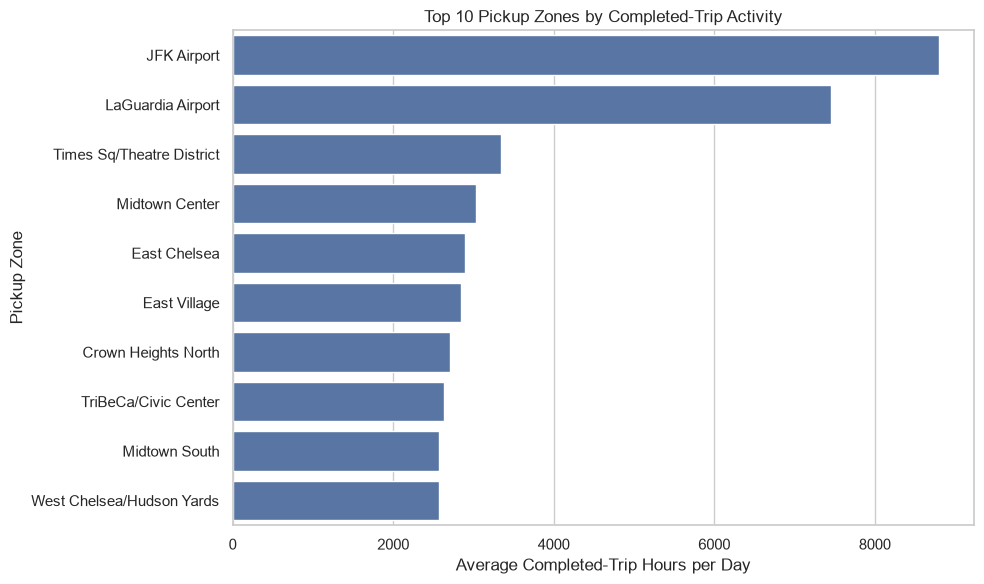

In [58]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_top_zone_activity,
    x='avg_completed_trip_hours_per_day',
    y='pickup_zone'
)

plt.title('Top 10 Pickup Zones by Completed-Trip Activity')
plt.xlabel('Average Completed-Trip Hours per Day')
plt.ylabel('Pickup Zone')
plt.tight_layout()
plt.show()

# 7. Final Validation

In [59]:
expected_zone_days = 366 * len(df_actionable_zones)

check_zone_days = len(df_daily_activity) == expected_zone_days
check_trip_total = (
    df_daily_activity['completed_trips'].sum()
    == df_daily_activity_raw['completed_trips'].sum()
)
check_missing_activity = (
    df_daily_activity[
        ['completed_trips', 'completed_trip_hours']
    ].isna().sum().sum() == 0
)
check_negative_activity = (
    (df_daily_activity['completed_trips'] < 0).sum() == 0
    and
    (df_daily_activity['completed_trip_hours'] < 0).sum() == 0
)
check_zone_count = (
    len(df_zone_activity) == len(df_actionable_zones)
)

In [98]:
print(f'Complete zone-day panel : {check_zone_days}')
print(f'Trip totals preserved   : {check_trip_total}')
print(f'No missing activity     : {check_missing_activity}')
print(f'No negative activity    : {check_negative_activity}')
print(f'Zone count preserved    : {check_zone_count}')

Complete zone-day panel : True
Trip totals preserved   : True
No missing activity     : True
No negative activity    : True
Zone count preserved    : True


In [99]:
con.close()